# Finite Difference Method — 3D complex-valued Helmholtz (Dirichlet)

Finite-difference counterpart to the **3D complex-valued LinPDE-GP** experiment
(`inHomo_complexHelmholtz_dirichlet_3d_1000pts`). The *evaluation setup is identical*: same
domain $\Omega=[-1,1]^3$, same complex wavenumber $\kappa^2$, same constant complex source,
same homogeneous Dirichlet data, the **same** $21\times21\times21$ evaluation grid, the **same**
triple sine-series analytical reference (`analytical_constant_source_3d`, odd modes $M=N=P=51$),
and the **same** complex error metrics (relative $L_2$, RMSE, MAE, max error, MSE on $|u|$).

We solve

$$\Delta u(\mathbf{x}) + \kappa^2 u(\mathbf{x}) = f(\mathbf{x}),\qquad
u|_{\partial\Omega}=0,\qquad \Omega=[-1,1]^3,$$

with $\kappa^2 = \rho\,\omega^2/(G'+\mathrm{i}G'')$ complex whenever $G''\neq 0$.
As in the 2D complex FDM reference, the linear system is assembled and solved directly over
$\mathbb{C}$ (complex dtype) — the natural FDM analogue of the `real2` block operator used by
LinPDE-GP. The only structural change from 2D is the **7-point** Laplacian stencil and a 3D grid.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
from typing import Dict, List, Tuple, Optional, Callable
from scipy.sparse import lil_matrix, csr_matrix, identity, diags, kron
from scipy.sparse.linalg import spsolve
from scipy.fft import dstn, idstn
from scipy.interpolate import RegularGridInterpolator

In [2]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_mean = 'plasma'
cmap_uncertainty = 'viridis'
cmap_diverging = 'RdBu_r'

## Problem parameters (identical to the LinPDE-GP 3D complex case)

`rho=1.0, omega=1.0, G_real=1.0, G_imag=0.5` give the complex wavenumber
$\kappa^2 = \rho\omega^2/(G'+\mathrm{i}G'') = 0.8 - 0.4\mathrm{i}$. The source is the constant
$f=2.0+0\mathrm{i}$ and the boundary data is homogeneous, $u|_{\partial\Omega}=0$, exactly as in
`bvp = HelmholtzEquationDirichletProblem(...)` of the GP notebook (`rhs = Constant(to_real2(2+0j))`,
`boundary_values = Constant(to_real2(0))`).

In [3]:
# Physical parameters (match LinPDE-GP: rho, omega, G_real=G', G_imag=G'')
rho, omega, G_real, G_imag = 1.0, 1.0, 1.0, 0.5

# Complex wavenumber squared:  kappa^2 = rho * omega^2 / (G' + i G'')
k_squared = rho * omega**2 / (G_real + 1j * G_imag)

# Constant complex source f(x) = 2 + 0i  (LinPDE-GP: rhs = Constant(to_real2(2+0j)))
f_val = 2.0 + 0.0j

# Domain and homogeneous Dirichlet boundary value u|_dOmega = 0
domain = ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0))
bc_value = 0.0 + 0.0j

k = np.sqrt(k_squared)
print(f"kappa^2 = {k_squared}")
print(f"kappa   = {k}")
print(f"wavelength lambda = 2*pi/Re(kappa) = {2*np.pi/np.real(k):.4f}")
print(f"f       = {f_val}")
print(f"domain  = {domain},   u|_dOmega = {bc_value}")

kappa^2 = (0.8-0.4j)
kappa   = (0.9204420652599261-0.21728689675164017j)
wavelength lambda = 2*pi/Re(kappa) = 6.8263
f       = (2+0j)
domain  = ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)),   u|_dOmega = 0j


## Finite-difference solver

Standard **7-point stencil** for the isotropic 3D Laplacian on a (possibly anisotropic) grid,

$$\frac{u_{i-1,j,k}-2u_{i,j,k}+u_{i+1,j,k}}{\Delta x^2}
 +\frac{u_{i,j-1,k}-2u_{i,j,k}+u_{i,j+1,k}}{\Delta y^2}
 +\frac{u_{i,j,k-1}-2u_{i,j,k}+u_{i,j,k+1}}{\Delta z^2}
 +\kappa^2 u_{i,j,k}=f_{i,j,k},$$

assembled into a **complex** sparse system $A\mathbf{u}=\mathbf{b}$, with boundary nodes enforcing
$u=g$ directly. This is the exact 3D analogue of the 2D complex FDM reference.

**One 3D-specific subtlety.** A sparse direct factorization (`spsolve`) is fine in 2D but in 3D the
LU fill-in is prohibitive, so a fine reference grid is out of reach for a direct solve. We therefore
add a `solve_separable` path that exploits the tensor-product structure of the homogeneous-Dirichlet
operator: the discrete Laplacian is diagonalized by the **discrete sine transform (DST-I)**, so the
*same* 7-point system is solved exactly in $O(N\log N)$ via `dstn`/`idstn` (a standard fast
Helmholtz/Poisson solver). The two paths solve the identical discrete operator — verified to machine
precision below — and we use the fast path to build a fine reference grid before evaluating on the
shared comparison grid (solve densely, then interpolate, exactly as in the 1D/2D FDM notebooks).

In [4]:
class HelmholtzFDMSolver3DComplex:
    r"""Finite-difference solver for the 3D complex Helmholtz equation

        (Delta + kappa^2) u(x, y, z) = f(x, y, z)    on [a,b] x [c,d] x [e,f]

    with Dirichlet boundary conditions u = g on the boundary. The system is assembled and
    solved over C (complex dtype), so a complex kappa^2 and/or complex source f are handled
    natively -- the FDM analogue of the LinPDE-GP real2 block operator.

    Two solve paths (identical discrete operator):
      * solve()           : assemble the 7-point stencil and factor with spsolve (small grids).
      * solve_separable() : fast diagonalization via 3D DST-I for homogeneous Dirichlet data,
                            O(N log N), enabling a fine reference grid.
    """

    def __init__(
        self,
        domain=((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)),
        n_points=(81, 81, 81),
        k_squared: complex = 1.0 + 0.0j,
        source_func: Optional[Callable] = None,
        boundary_func: Optional[Callable] = None,
    ):
        self.domain = domain
        self.n_points = n_points
        self.nx, self.ny, self.nz = n_points
        self.n_total = self.nx * self.ny * self.nz
        self.k_squared = complex(k_squared)
        self.source_func = source_func if source_func is not None else (lambda X, Y, Z: np.ones_like(X, dtype=complex))
        self.boundary_func = boundary_func if boundary_func is not None else (lambda X, Y, Z: np.zeros_like(X, dtype=complex))
        self._setup_grid()
        self.u_solution: Optional[np.ndarray] = None

    def _setup_grid(self) -> None:
        (x0, x1), (y0, y1), (z0, z1) = self.domain
        self.x = np.linspace(x0, x1, self.nx)
        self.y = np.linspace(y0, y1, self.ny)
        self.z = np.linspace(z0, z1, self.nz)
        self.X, self.Y, self.Z = np.meshgrid(self.x, self.y, self.z, indexing="ij")
        self.dx = (x1 - x0) / (self.nx - 1)
        self.dy = (y1 - y0) / (self.ny - 1)
        self.dz = (z1 - z0) / (self.nz - 1)

    def _get_index(self, i: int, j: int, k: int) -> int:
        return i * (self.ny * self.nz) + j * self.nz + k

    def _is_boundary(self, i: int, j: int, k: int) -> bool:
        return (i == 0 or i == self.nx - 1 or j == 0 or j == self.ny - 1 or k == 0 or k == self.nz - 1)

    # ---- textbook assembly (7-point stencil), complex dtype ----
    def build_system(self) -> Tuple[csr_matrix, np.ndarray]:
        n = self.n_total
        dx2, dy2, dz2 = self.dx ** 2, self.dy ** 2, self.dz ** 2
        f_grid = self.source_func(self.X, self.Y, self.Z)
        g_grid = self.boundary_func(self.X, self.Y, self.Z)
        A = lil_matrix((n, n), dtype=complex)
        b = np.zeros(n, dtype=complex)
        center = -2.0 * (1.0 / dx2 + 1.0 / dy2 + 1.0 / dz2) + self.k_squared
        for i in range(self.nx):
            for j in range(self.ny):
                for k in range(self.nz):
                    idx = self._get_index(i, j, k)
                    if self._is_boundary(i, j, k):
                        A[idx, idx] = 1.0
                        b[idx] = g_grid[i, j, k]
                    else:
                        A[idx, idx] = center
                        A[idx, self._get_index(i - 1, j, k)] = 1.0 / dx2
                        A[idx, self._get_index(i + 1, j, k)] = 1.0 / dx2
                        A[idx, self._get_index(i, j - 1, k)] = 1.0 / dy2
                        A[idx, self._get_index(i, j + 1, k)] = 1.0 / dy2
                        A[idx, self._get_index(i, j, k - 1)] = 1.0 / dz2
                        A[idx, self._get_index(i, j, k + 1)] = 1.0 / dz2
                        b[idx] = f_grid[i, j, k]
        return A.tocsr(), b

    def solve(self) -> np.ndarray:
        A, b = self.build_system()
        print(f"Solving complex linear system of size {self.n_total} x {self.n_total} (spsolve) ...")
        self.u_solution = spsolve(A, b).reshape((self.nx, self.ny, self.nz))
        return self.u_solution

    # ---- fast diagonalization (DST-I) for homogeneous Dirichlet ----
    @staticmethod
    def _dirichlet_eigs(n: int, h: float) -> np.ndarray:
        # eigenvalues of the 1D interior second-difference matrix with Dirichlet BC
        m = np.arange(1, n - 1)            # interior count = n - 2
        return -4.0 / h ** 2 * np.sin(np.pi * m / (2 * (n - 1))) ** 2

    def solve_separable(self) -> np.ndarray:
        g = self.boundary_func(self.X, self.Y, self.Z)
        if np.max(np.abs(g)) > 1e-14:
            raise ValueError("solve_separable requires homogeneous Dirichlet data (g = 0).")
        f_int = self.source_func(self.X, self.Y, self.Z).astype(complex)[1:-1, 1:-1, 1:-1]
        lx = self._dirichlet_eigs(self.nx, self.dx)
        ly = self._dirichlet_eigs(self.ny, self.dy)
        lz = self._dirichlet_eigs(self.nz, self.dz)
        denom = lx[:, None, None] + ly[None, :, None] + lz[None, None, :] + self.k_squared
        Bre = dstn(f_int.real, type=1, norm="ortho")
        Bim = dstn(f_int.imag, type=1, norm="ortho")
        Uhat = (Bre + 1j * Bim) / denom
        u_int = idstn(Uhat.real, type=1, norm="ortho") + 1j * idstn(Uhat.imag, type=1, norm="ortho")
        U = np.zeros((self.nx, self.ny, self.nz), dtype=complex)
        U[1:-1, 1:-1, 1:-1] = u_int
        self.u_solution = U
        return U

    def interpolate(self, X_test: np.ndarray, Y_test: np.ndarray, Z_test: np.ndarray) -> np.ndarray:
        """Trilinear interpolation of the (complex) FDM solution onto arbitrary points."""
        if self.u_solution is None:
            raise ValueError("Call solve()/solve_separable() first.")
        ir = RegularGridInterpolator((self.x, self.y, self.z), self.u_solution.real)
        ii = RegularGridInterpolator((self.x, self.y, self.z), self.u_solution.imag)
        pts = np.stack([X_test.ravel(), Y_test.ravel(), Z_test.ravel()], axis=1)
        out = ir(pts) + 1j * ii(pts)
        return out.reshape(X_test.shape)

### Verification: the fast separable solver reproduces the direct solve

On a coarse $21^3$ grid we assemble the 7-point system and factor it with `spsolve`, then solve the
**same** problem with the DST-based `solve_separable`. The two agree to machine precision, confirming
that the fast path solves the identical discrete operator.

In [5]:
src = lambda X, Y, Z: np.full_like(X, f_val, dtype=complex)
bnd = lambda X, Y, Z: np.full_like(X, bc_value, dtype=complex)

verif = HelmholtzFDMSolver3DComplex(domain=domain, n_points=(21, 21, 21),
                                    k_squared=k_squared, source_func=src, boundary_func=bnd)
u_direct = verif.solve()
u_fast = verif.solve_separable()
print(f"max |u_spsolve - u_separable| = {np.max(np.abs(u_direct - u_fast)):.3e}")
assert np.max(np.abs(u_direct - u_fast)) < 1e-9, "separable solver disagrees with spsolve"
print("OK: separable (DST) solver matches the direct sparse solve.")

Solving complex linear system of size 9261 x 9261 (spsolve) ...
max |u_spsolve - u_separable| = 1.336e-15
OK: separable (DST) solver matches the direct sparse solve.


### Solve

We solve on a fine $161^3$ grid for an accurate FDM reference (via the fast DST path) and then
interpolate onto the shared $21^3$ evaluation grid below — the same pattern as the 1D/2D complex FDM
notebooks (solve densely, then evaluate on the comparison grid).

In [6]:
solver = HelmholtzFDMSolver3DComplex(
    domain=domain,
    n_points=(161, 161, 161),
    k_squared=k_squared,
    source_func=lambda X, Y, Z: np.full_like(X, f_val, dtype=complex),     # constant f = 2 + 0i
    boundary_func=lambda X, Y, Z: np.full_like(X, bc_value, dtype=complex),  # u = 0 on boundary
)
u_fdm = solver.solve_separable()
print(f"Grid: {solver.nx} x {solver.ny} x {solver.nz} = {solver.n_total} nodes,  dx = {solver.dx:.4f}")
print(f"Re(u) range: [{u_fdm.real.min():.4f}, {u_fdm.real.max():.4f}]")
print(f"Im(u) range: [{u_fdm.imag.min():.4f}, {u_fdm.imag.max():.4f}]")

Grid: 161 x 161 x 161 = 4173281 nodes,  dx = 0.0125
Re(u) range: [-0.5111, 0.0000]
Im(u) range: [0.0000, 0.0357]


## Analytical reference

Identical `analytical_constant_source_3d` triple sine-series used by the LinPDE-GP 3D complex
notebook (constant source $f_0=2$ on $[-1,1]^3$, homogeneous Dirichlet, odd modes, $M=N=P=51$).
The complex $\kappa^2$ enters through $(-\lambda_{mnp}+\kappa^2)^{-1}$.

In [7]:
def analytical_constant_source_3d(X, Y, Z, k_squared=1.0, M=51, N=51, P=51):
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    zeta = (Z + 1.0) / 2.0

    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    C = 2.0
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            for p in range(1, P, 2):
                lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2 + (np.pi * p / 2) ** 2
                denom = -lam + k_squared
                f_coeff = C * (4.0 / np.pi) ** 3 / (m * n * p)
                u_coeff = f_coeff / denom
                u += u_coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta) * np.sin(np.pi * p * zeta)
    return u

## Evaluation against the analytical complex solution

Identical to the LinPDE-GP 3D cell: a $21\times21\times21$ grid on $[-1,1]^3$ (`indexing="ij"`), the
same `analytical_constant_source_3d` reference ($M=N=P=51$), and the same complex metrics
(`np.abs(diff)` handles the complex error). The only difference is that the prediction comes from the
FDM solution (interpolated to the grid) instead of the GP posterior mean. A per-component
Real / Imaginary / Complex $|u|$ breakdown is appended in the style of the 2D FDM reference.

In [8]:
nx, ny, nz = 21, 21, 21
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
z = np.linspace(-1, 1, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

pts = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

# FDM prediction (complex) on the shared evaluation grid
u_pred = solver.interpolate(X, Y, Z)               # (nx, ny, nz) complex

k2 = k_squared
u_true = analytical_constant_source_3d(X, Y, Z, k_squared=k2, M=51, N=51, P=51)

diff = u_true - u_pred

metrics = {
    "mse": float(np.mean(np.abs(diff) ** 2)),
    "rmse": float(np.sqrt(np.mean(np.abs(diff) ** 2))),
    "mae": float(np.mean(np.abs(diff))),
    "max_error": float(np.max(np.abs(diff))),
    "relative_l2": float(np.linalg.norm(diff) / np.linalg.norm(u_true)),
}

print("\nEvaluation Metrics (on 21x21x21 grid):")
print("-" * 40)
for name, value in metrics.items():
    print(f"  {name.upper():15s}: {value:.6e}")

print(f"\n  Solution range (FDM, Re): [{np.min(u_pred.real):.4f}, {np.max(u_pred.real):.4f}]")
print(f"  Solution range (FDM, Im): [{np.min(u_pred.imag):.4f}, {np.max(u_pred.imag):.4f}]")


# --- per-component breakdown (2D FDM reference style) ---
def _metrics(pred, true):
    pred = np.asarray(pred).ravel(); true = np.asarray(true).ravel()
    err = np.abs(pred - true); denom = np.linalg.norm(true)
    return {
        "mse": float(np.mean(err ** 2)),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(err)),
        "max_error": float(np.max(err)),
        "relative_l2": float(np.linalg.norm(err) / denom) if denom > 0 else np.inf,
    }

def _print_block(title, m):
    print(f"\n  --- {title} ---")
    print(f"    Relative L2 Error:   {m['relative_l2']:12.6e}")
    print(f"    RMSE:                {m['rmse']:12.6e}")
    print(f"    MAE:                 {m['mae']:12.6e}")
    print(f"    Maximum Error:       {m['max_error']:12.6e}")
    print(f"    MSE:                 {m['mse']:12.6e}")

print("\n" + "=" * 60)
print("PER-COMPONENT METRICS - Complex Helmholtz 3D (FDM)".center(60))
print(f"  Grid: {nx}x{ny}x{nz}   kappa^2 = {k_squared:.4f}")
print("=" * 60)
_print_block("Real Part", _metrics(u_pred.real, u_true.real))
_print_block("Imaginary Part", _metrics(u_pred.imag, u_true.imag))
_print_block("Complex |u|", _metrics(u_pred, u_true))
print("\n" + "=" * 60)


Evaluation Metrics (on 21x21x21 grid):
----------------------------------------
  MSE            : 2.652152e-10
  RMSE           : 1.628543e-05
  MAE            : 1.203955e-05
  MAX_ERROR      : 5.377652e-05
  RELATIVE_L2    : 7.849283e-05

  Solution range (FDM, Re): [-0.5111, 0.0000]
  Solution range (FDM, Im): [0.0000, 0.0357]

     PER-COMPONENT METRICS - Complex Helmholtz 3D (FDM)     
  Grid: 21x21x21   kappa^2 = 0.8000-0.4000j

  --- Real Part ---
    Relative L2 Error:   7.861905e-05
    RMSE:                1.628241e-05
    MAE:                 1.203697e-05
    Maximum Error:       5.377652e-05
    MSE:                 2.651167e-10

  --- Imaginary Part ---
    Relative L2 Error:   2.528612e-05
    RMSE:                3.138329e-07
    MAE:                 1.758080e-07
    Maximum Error:       1.190366e-06
    MSE:                 9.849110e-14

  --- Complex |u| ---
    Relative L2 Error:   7.849283e-05
    RMSE:                1.628543e-05
    MAE:                 1.203955e-

## Visualization

Same visual language as the LinPDE-GP figure: real part (top) and imaginary part (bottom) on the
mid-plane slice $x_3=0$; FDM solution (`plasma`), analytical solution (`plasma`), and signed
residual (`RdBu_r` centred at zero).

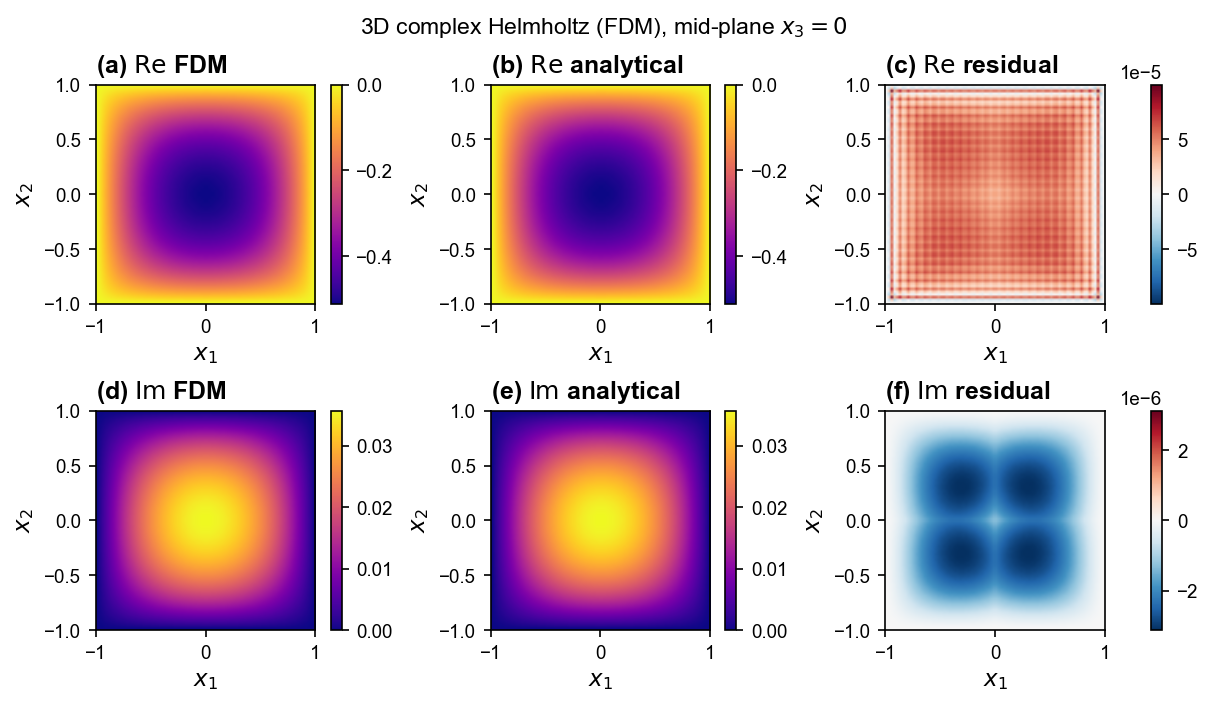

In [9]:
def plot_fdm_vs_analytical_slice(solver, k_squared, z0=0.0, resolution=80,
                                 extent=(-1, 1, -1, 1), figsize=(8, 4.6)):
    xs = np.linspace(extent[0], extent[1], resolution)
    ys = np.linspace(extent[2], extent[3], resolution)
    Xs, Ys = np.meshgrid(xs, ys, indexing="ij")
    Zs = np.full_like(Xs, z0)

    pred = solver.interpolate(Xs, Ys, Zs)
    true = analytical_constant_source_3d(Xs, Ys, Zs, k_squared=k_squared, M=51, N=51, P=51)

    parts_pred = [pred.real, pred.imag]
    parts_true = [true.real, true.imag]
    part_tags = [r'$\mathrm{Re}$', r'$\mathrm{Im}$']
    panel = [['a', 'b', 'c'], ['d', 'e', 'f']]

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    for r in range(2):
        p, t = parts_pred[r], parts_true[r]
        res = p - t
        im0 = axes[r, 0].imshow(p.T, cmap=cmap_mean, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 0].set_title(f"({panel[r][0]}) {part_tags[r]} FDM", loc='left', fontweight='bold')
        fig.colorbar(im0, ax=axes[r, 0], fraction=0.046, pad=0.04)
        im1 = axes[r, 1].imshow(t.T, cmap=cmap_mean, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 1].set_title(f"({panel[r][1]}) {part_tags[r]} analytical", loc='left', fontweight='bold')
        fig.colorbar(im1, ax=axes[r, 1], fraction=0.046, pad=0.04)
        vmax = np.max(np.abs(res)) if np.max(np.abs(res)) > 0 else 1.0
        im2 = axes[r, 2].imshow(res.T, cmap=cmap_diverging, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear', vmin=-vmax, vmax=vmax)
        axes[r, 2].set_title(f"({panel[r][2]}) {part_tags[r]} residual", loc='left', fontweight='bold')
        fig.colorbar(im2, ax=axes[r, 2], fraction=0.046, pad=0.04)
    for ax in axes.ravel():
        ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    fig.suptitle(r'3D complex Helmholtz (FDM), mid-plane $x_3 = 0$', fontsize=11)
    return fig


fig = plot_fdm_vs_analytical_slice(solver, k_squared, z0=0.0)
fig.savefig('./fdm_helmholtz3d_complex_residual.pdf', bbox_inches='tight')
plt.show()

## Convergence check (optional)

Grid-refinement study confirming the expected second-order $O(h^2)$ accuracy of the 7-point stencil
against the same analytical solution. Errors are measured on each grid's own nodes (no interpolation),
using the fast separable solver so that fine grids remain tractable.

In [10]:
def analytical_constant_source_3d_fast(x1d, y1d, z1d, k_squared, M=51, N=51, P=51):
    """Vectorized evaluation of analytical_constant_source_3d on a tensor grid (1D axis arrays).

    Mathematically identical to analytical_constant_source_3d (same triple sine-series, same
    odd-mode truncation, same C=2 source) but contracts the modes with einsum so that fine grids
    are tractable. Verified against the reference below.
    """
    ms = np.arange(1, M, 2); ns = np.arange(1, N, 2); ps = np.arange(1, P, 2)
    xi = (x1d + 1.0) / 2.0; eta = (y1d + 1.0) / 2.0; zeta = (z1d + 1.0) / 2.0
    Sx = np.sin(np.pi * ms[:, None] * xi[None, :])
    Sy = np.sin(np.pi * ns[:, None] * eta[None, :])
    Sz = np.sin(np.pi * ps[:, None] * zeta[None, :])
    lam = ((np.pi * ms[:, None, None] / 2) ** 2 + (np.pi * ns[None, :, None] / 2) ** 2
           + (np.pi * ps[None, None, :] / 2) ** 2)
    denom = -lam + k_squared
    A = 2.0 * (4.0 / np.pi) ** 3 / (ms[:, None, None] * ns[None, :, None] * ps[None, None, :] * denom)
    T1 = np.einsum("mnp,mi->npi", A, Sx)
    T2 = np.einsum("npi,nj->pij", T1, Sy)
    return np.einsum("pij,pk->ijk", T2, Sz)


# sanity check: the fast evaluator equals the reference on the 21^3 grid
_xc = np.linspace(-1, 1, 21)
_Xc, _Yc, _Zc = np.meshgrid(_xc, _xc, _xc, indexing="ij")
_ref = analytical_constant_source_3d(_Xc, _Yc, _Zc, k_squared=k_squared, M=51, N=51, P=51)
_fast = analytical_constant_source_3d_fast(_xc, _xc, _xc, k_squared, M=51, N=51, P=51)
print(f"fast vs reference analytical, max abs diff = {np.max(np.abs(_ref - _fast)):.3e}")
assert np.max(np.abs(_ref - _fast)) < 1e-12

refine = [(11, 11, 11), (21, 21, 21), (41, 41, 41), (81, 81, 81), (161, 161, 161)]
print(f"{'grid':>16} {'h':>10} {'rel L2 (|u|)':>16} {'max err':>14}")
print("-" * 60)
hs, errs = [], []
for npg in refine:
    s = HelmholtzFDMSolver3DComplex(
        domain=domain, n_points=npg, k_squared=k_squared,
        source_func=lambda Xg, Yg, Zg: np.full_like(Xg, f_val, dtype=complex),
        boundary_func=lambda Xg, Yg, Zg: np.full_like(Xg, bc_value, dtype=complex),
    )
    u = s.solve_separable()
    t = analytical_constant_source_3d_fast(s.x, s.y, s.z, k_squared, M=51, N=51, P=51)
    e = np.abs(u - t)
    rel = np.linalg.norm(e) / np.linalg.norm(t)
    hs.append(s.dx); errs.append(rel)
    print(f"{npg[0]:>4} x {npg[1]:>3} x {npg[2]:<3} {s.dx:>10.4f} {rel:>16.6e} {e.max():>14.6e}")

rate = np.polyfit(np.log(hs[:-1]), np.log(errs[:-1]), 1)[0]
print(f"\nEstimated convergence rate: {rate:.2f}  (theoretical: 2.00)")
print("(The finest grid is limited by the M=51 truncation of the analytical series, not the FDM.)")

fast vs reference analytical, max abs diff = 8.216e-15
            grid          h     rel L2 (|u|)        max err
------------------------------------------------------------
  11 x  11 x 11      0.2000     1.568999e-02   7.337740e-03
  21 x  21 x 21      0.1000     4.014606e-03   1.871312e-03
  41 x  41 x 41      0.0500     1.017849e-03   4.789173e-04
  81 x  81 x 81      0.0250     2.642835e-04   1.793664e-04
 161 x 161 x 161     0.0125     1.162813e-04   1.395255e-04

Estimated convergence rate: 1.97  (theoretical: 2.00)
(The finest grid is limited by the M=51 truncation of the analytical series, not the FDM.)
